# Ejercicio 4. Análisis exploratorio con DuckDB

Viajes de taxis amarillos y verdes de enero a agosto de 2026. Salvo donde se indique, las consultas usan la vista viajes_validos, que conserva el 95% de los registros después de las reglas de calidad del ejercicio 3.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = duckdb.connect()


def consulta(ruta):
    """Imprime un archivo de sql, lo ejecuta y muestra el tiempo"""
    texto = Path("sql", ruta).read_text(encoding="utf-8")
    print(texto)
    inicio = time.perf_counter()
    resultado = con.execute(texto).df()
    print(f"-- {time.perf_counter() - inicio:.2f} s")
    return resultado

con.execute(Path("sql/vistas.sql").read_text(encoding="utf-8"))

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR = {"yellow": "#eda100", "green": "#008300"}
NOMBRE = {"yellow": "Amarillo", "green": "Verde"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")

## 4.1 Preguntas

| # | Pregunta | Aspecto | Por qué en estos datos |
| --- | --- | --- | --- |
| P1 | ¿Cómo cambia el número de viajes de un mes a otro? | Temporal | Cada archivo es un mes y cada viaje tiene fecha y hora de inicio |
| P2 | ¿En qué horas y días se concentran los viajes? | Temporal | La hora de inicio separa días hábiles y fin de semana |
| P3 | ¿Qué distancia, duración, velocidad y total tiene un viaje típico? | Características y distribución | Distancia, fechas y total tienen colas largas (ejercicio 3) |
| P4 | ¿Dónde empiezan los viajes? | Características y tipos de taxi | PULocationID se une al catálogo de zonas, y los taxis verdes no pueden recoger pasajeros en la calle al sur de la calle 96 Este y la 110 Oeste de Manhattan |
| P5 | ¿En qué se diferencian los taxis amarillos y verdes? | Tipos de taxi | Los dos comparten 18 columnas y admiten los mismos indicadores |
| P6 | ¿Cómo pagan los pasajeros y cuánta propina dejan? | Pago | payment_type y tip_amount, con la propina en efectivo sin registrar |
| P7 | ¿Qué parte del total son recargos y cambió alguno en 2026? | Pago | El total suma tarifa, propina, peajes y seis cargos |
| P8 | ¿Qué explica los totales atípicos entre los viajes válidos? | Atípicos | El total va de 1 a más de 1,000 dólares aun después de filtrar |
| P9 | ¿Cuántos viajes son Flex Fare y de dónde vienen? | Pago e inconsistencias | Una cuarta parte de los amarillos tiene nulos en cinco columnas (ejercicio 3) |

## 4.2 a 4.4 Consultas y resultados

### P1. ¿Cómo cambia el número de viajes de un mes a otro?

Los viajes de cada mes se dividen entre sus días para comparar febrero con meses de 31 días.

In [2]:
mensual = consulta("ej4/01_viajes_por_mes.sql")
mensual

-- Viajes válidos por mes y tipo de taxi
SELECT
    taxi,
    periodo,
    count(*) AS viajes,
    round(count(*) / day(last_day(periodo))) AS viajes_por_dia
FROM viajes_validos
GROUP BY taxi, periodo
ORDER BY taxi DESC, periodo



-- 0.31 s


,taxi,periodo,viajes,viajes_por_dia
0,yellow,2026-01-01,3515440,113401.0
1,yellow,2026-02-01,3209333,114619.0
2,yellow,2026-03-01,3761730,121346.0
3,yellow,2026-04-01,3673102,122437.0
4,yellow,2026-05-01,3910896,126158.0
5,yellow,2026-06-01,3645451,121515.0
6,yellow,2026-07-01,3345122,107907.0
7,yellow,2026-08-01,3162692,102022.0
8,green,2026-01-01,38564,1244.0
9,green,2026-02-01,35578,1271.0


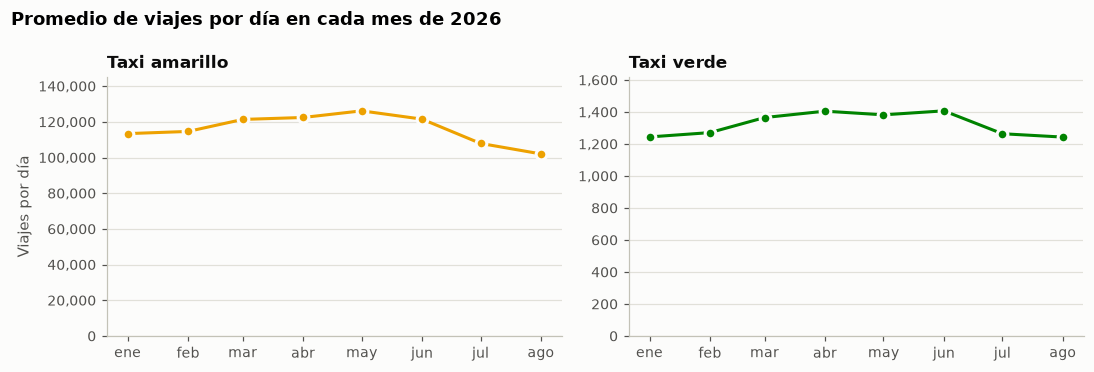

In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.4))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = mensual[mensual.taxi == taxi]
    eje.plot(d.periodo, d.viajes_por_dia, color=COLOR[taxi], marker="o", markersize=7,
             markeredgecolor="#fcfcfb", markeredgewidth=2)
    eje.set_title(f"Taxi {NOMBRE[taxi].lower()}")
    eje.set_ylim(0, d.viajes_por_dia.max() * 1.15)
    eje.yaxis.set_major_formatter(miles)
    eje.set_xticks(d.periodo, [MESES[p.month - 1] for p in d.periodo])
ejes[0].set_ylabel("Viajes por día")
fig.suptitle("Promedio de viajes por día en cada mes de 2026", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

Los amarillos suben de 113 mil viajes por día en enero a 126 mil en mayo y bajan a 102 mil en agosto, 19% menos que en mayo. Los verdes se mueven entre 1,243 y 1,407 viajes por día con el mismo arco. Suben hasta abril y junio y bajan en julio y agosto.

### P2. ¿En qué horas y días se concentran los viajes?

Porcentaje de los viajes de cada tipo que empieza en cada hora, de lunes a viernes y en fin de semana, y promedio de viajes por fecha según el día de la semana.

In [4]:
horas = consulta("ej4/02_viajes_por_hora.sql")
horas.pivot_table(index="hora", columns=["taxi", "dias"], values="pct")

-- Porcentaje de viajes por hora de inicio, de lunes a viernes y en fin de semana
WITH conteo AS (
    SELECT
        taxi,
        CASE WHEN isodow(pickup_datetime) <= 5 THEN 'Lunes a viernes' ELSE 'Sábado y domingo' END AS dias,
        hour(pickup_datetime) AS hora,
        count(*) AS viajes
    FROM viajes_validos
    GROUP BY taxi, dias, hora
)
SELECT
    taxi,
    dias,
    hora,
    viajes,
    round(100 * viajes / sum(viajes) OVER (PARTITION BY taxi, dias), 2) AS pct
FROM conteo
ORDER BY taxi DESC, dias, hora



-- 0.32 s


taxi           green                           yellow                 
dias Lunes a viernes Sábado y domingo Lunes a viernes Sábado y domingo
hora                                                                  
0               1.03             2.92            2.13             5.85
1               0.53             2.11            1.12             4.60
2               0.30             1.78            0.64             3.32
3               0.21             1.59            0.44             2.42
4               0.33             1.21            0.52             1.61
5               0.76             0.71            0.96             0.83
6               2.41             0.83            2.02             1.06
7               5.12             1.67            3.73             1.36
8               6.36             2.37            4.94             1.98
9               6.28             3.75            4.78             3.01
10              5.81             4.47            4.52             3.84
11              5.47             5.29            4.71             4.56
12              5.73             6.35            5.01             5.12
13              5.60             6.37            5.20             5.47
14              6.34             6.86            5.78             5.58
15              6.93             7.21            6.07             5.53
16              7.62             7.27            5.64             5.74
17              8.05             6.95            6.38             5.96
18              7.36             7.31            6.61             6.21
19              5.32             6.11            5.95             5.78
20              3.95             5.08            6.17             5.11
21              3.50             4.53            6.51             5.05
22              2.98             3.98            5.83             5.17
23              2.00             3.27            4.34             4.82

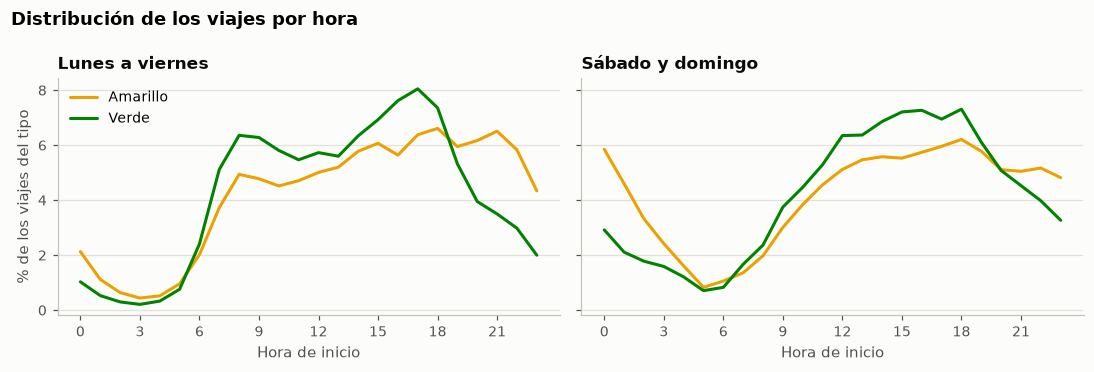

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for eje, dias in zip(ejes, ["Lunes a viernes", "Sábado y domingo"]):
    for taxi in ["yellow", "green"]:
        d = horas[(horas.taxi == taxi) & (horas.dias == dias)]
        eje.plot(d.hora, d.pct, color=COLOR[taxi], label=NOMBRE[taxi])
    eje.set_title(dias)
    eje.set_xticks(range(0, 24, 3))
    eje.set_xlabel("Hora de inicio")
ejes[0].set_ylabel("% de los viajes del tipo")
ejes[0].legend(loc="upper left")
fig.suptitle("Distribución de los viajes por hora", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

In [6]:
consulta("ej4/03_viajes_por_dia.sql")

-- Promedio de viajes por fecha según el día de la semana
WITH por_fecha AS (
    SELECT taxi, CAST(pickup_datetime AS DATE) AS fecha, count(*) AS viajes
    FROM viajes_validos
    GROUP BY taxi, fecha
)
SELECT
    taxi,
    isodow(fecha) AS dia_semana,
    ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo'][isodow(fecha)] AS dia,
    count(*) AS fechas,
    round(avg(viajes)) AS viajes_por_dia
FROM por_fecha
GROUP BY taxi, dia_semana, dia
ORDER BY taxi DESC, dia_semana



-- 0.30 s


,taxi,dia_semana,dia,fechas,viajes_por_dia
0,yellow,1,lunes,35,95851.0
1,yellow,2,martes,34,113106.0
2,yellow,3,miércoles,34,120552.0
3,yellow,4,jueves,35,127357.0
4,yellow,5,viernes,35,120601.0
5,yellow,6,sábado,35,128610.0
6,yellow,7,domingo,35,106992.0
7,green,1,lunes,35,1312.0
8,green,2,martes,34,1431.0
9,green,3,miércoles,34,1485.0


De lunes a viernes, los verdes tienen un pico de mañana a las 8 h, con el 6.36% de sus viajes, y el máximo a las 17 h, con el 8.05%. Los amarillos crecen durante el día, llegan al 6.6% a las 18 h y se mantienen hasta las 22 h. En fin de semana los dos tipos mueven viajes a la madrugada. Entre las 0 y las 3:59 h ocurre el 16.2% de los viajes amarillos del fin de semana, contra el 4.3% en días hábiles.

Por día de la semana, los amarillos tienen su mayor promedio el sábado (128,610 viajes) y el menor el lunes (95,851). Los verdes llegan al máximo el jueves (1,520) y bajan en sábado y domingo. Los amarillos atienden más la vida nocturna y de fin de semana, y los verdes, traslados de día laboral.

### P3. ¿Qué distancia, duración, velocidad y total tiene un viaje típico?

Percentiles de cada variable y porcentaje de viajes por intervalo de distancia y de total.

In [7]:
consulta("ej4/04_distribuciones.sql")

-- Percentiles de distancia, duración, velocidad y total por tipo de taxi
-- Cada variable se agrega por separado para no juntar cientos de millones de valores en una sola agregación
WITH medidas AS (
    SELECT 'distancia (millas)' AS variable, taxi,
           quantile_cont(trip_distance, [0.05, 0.25, 0.5, 0.75, 0.95]) AS q, avg(trip_distance) AS promedio
    FROM viajes_validos GROUP BY taxi
    UNION ALL
    SELECT 'duración (min)', taxi,
           quantile_cont(duracion_min, [0.05, 0.25, 0.5, 0.75, 0.95]), avg(duracion_min)
    FROM viajes_validos GROUP BY taxi
    UNION ALL
    SELECT 'velocidad (mph)', taxi,
           quantile_cont(trip_distance / (duracion_min / 60), [0.05, 0.25, 0.5, 0.75, 0.95]),
           avg(trip_distance / (duracion_min / 60))
    FROM viajes_validos GROUP BY taxi
    UNION ALL
    SELECT 'total (USD)', taxi,
           quantile_cont(total_amount, [0.05, 0.25, 0.5, 0.75, 0.95]), avg(total_amount)
    FROM viajes_validos GROUP BY taxi
)
SELECT
    variab

-- 3.15 s


,variable,taxi,p05,p25,mediana,p75,p95,promedio
0,distancia (millas),yellow,0.50,1.10,1.93,3.95,12.52,3.51
1,distancia (millas),green,0.64,1.33,2.14,3.77,10.61,3.35
2,duración (min),yellow,4.03,8.62,14.10,22.25,44.02,17.67
3,duración (min),green,4.27,8.72,13.33,20.62,43.93,17.15
4,total (USD),yellow,12.49,17.50,23.58,34.50,77.25,30.24
5,total (USD),green,9.88,15.12,20.52,29.70,56.29,25.36
6,velocidad (mph),yellow,3.95,6.83,9.28,12.93,24.07,10.88
7,velocidad (mph),green,5.27,7.95,10.04,13.09,22.48,11.37


-- Porcentaje de viajes por intervalo de distancia (1 milla) y de total (5 USD)
WITH totales AS (
    SELECT taxi, count(*) AS viajes_taxi
    FROM viajes_validos
    GROUP BY taxi
),
intervalos AS (
    SELECT taxi, 'distancia' AS variable, floor(trip_distance) AS desde, count(*) AS viajes
    FROM viajes_validos
    WHERE trip_distance < 25
    GROUP BY ALL
    UNION ALL
    SELECT taxi, 'total', floor(total_amount / 5) * 5, count(*)
    FROM viajes_validos
    WHERE total_amount < 125
    GROUP BY ALL
)
SELECT
    i.variable,
    i.taxi,
    i.desde,
    i.viajes,
    round(100 * i.viajes / t.viajes_taxi, 2) AS pct
FROM intervalos AS i
JOIN totales AS t USING (taxi)
ORDER BY i.variable, i.taxi DESC, i.desde



-- 0.88 s


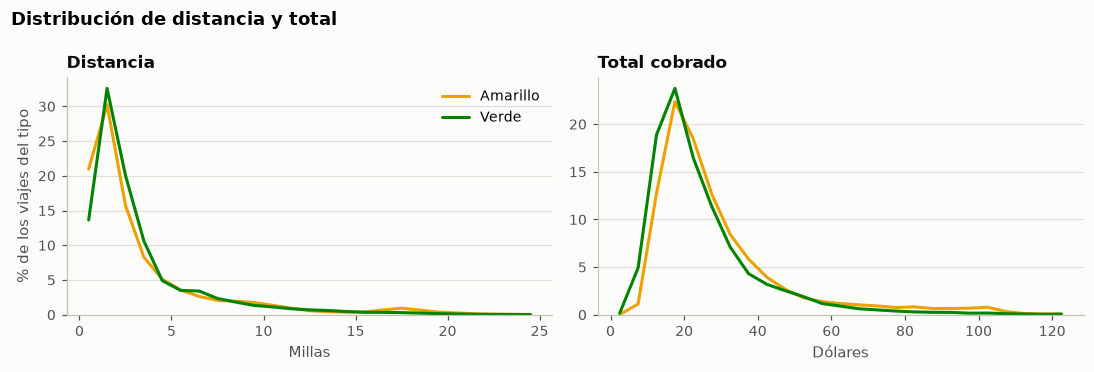

In [8]:
histogramas = consulta("ej4/05_histogramas.sql")
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.4))
titulos = {"distancia": ("Distancia", "Millas"), "total": ("Total cobrado", "Dólares")}
for eje, variable in zip(ejes, ["distancia", "total"]):
    for taxi in ["yellow", "green"]:
        d = histogramas[(histogramas.variable == variable) & (histogramas.taxi == taxi)]
        ancho = 1 if variable == "distancia" else 5
        eje.plot(d.desde + ancho / 2, d.pct, color=COLOR[taxi], label=NOMBRE[taxi])
    eje.set_title(titulos[variable][0])
    eje.set_xlabel(titulos[variable][1])
    eje.set_ylim(bottom=0)
ejes[0].set_ylabel("% de los viajes del tipo")
ejes[0].legend()
fig.suptitle("Distribución de distancia y total", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

La mitad de los viajes amarillos recorre menos de 1.93 millas, dura menos de 14.1 minutos y cuesta menos de 23.58 dólares. En la mediana, los verdes recorren más (2.14 millas) y pagan menos (20.52 dólares). Las distribuciones tienen cola a la derecha. En amarillos el promedio de distancia, 3.51 millas, casi duplica la mediana y el 5% de los viajes pasa de 12.5 millas. El total amarillo tiene un segundo aumento cerca de 100 dólares, que coincide con la tarifa fija de JFK (P8). La velocidad mediana va de 9 a 10 millas por hora.

### P4. ¿Dónde empiezan los viajes?

Distrito y zona donde empieza cada viaje, según el catálogo de zonas de la TLC.

In [9]:
distritos = consulta("ej4/06_distritos.sql")
distritos

-- Distrito donde empiezan los viajes por tipo de taxi
SELECT
    v.taxi,
    z.distrito,
    count(*) AS viajes,
    round(100 * count(*) / sum(count(*)) OVER (PARTITION BY v.taxi), 1) AS pct
FROM viajes_validos AS v
JOIN zonas AS z ON v.PULocationID = z.zona_id
GROUP BY v.taxi, z.distrito
ORDER BY v.taxi DESC, viajes DESC



-- 0.38 s


,taxi,distrito,viajes,pct
0,yellow,Manhattan,24455090,86.6
1,yellow,Queens,2496082,8.8
2,yellow,Brooklyn,1015515,3.6
3,yellow,Bronx,218030,0.8
4,yellow,Unknown,29375,0.1
5,yellow,N/A,6126,0.0
6,yellow,Staten Island,2660,0.0
7,yellow,EWR,888,0.0
8,green,Manhattan,191656,59.6
9,green,Queens,70694,22.0


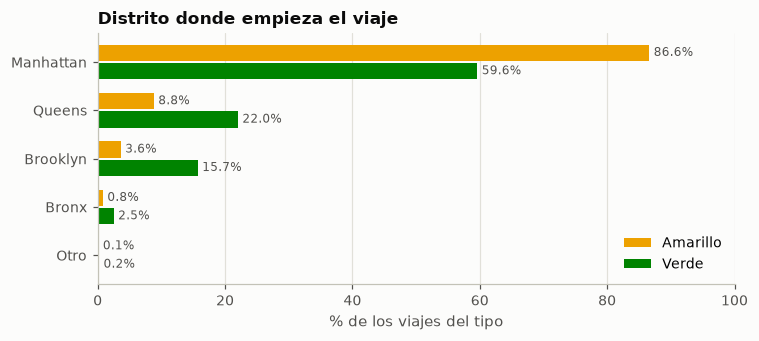

In [10]:
import numpy as np

orden = ["Manhattan", "Queens", "Brooklyn", "Bronx"]
d = distritos.assign(distrito=distritos.distrito.where(distritos.distrito.isin(orden), "Otro"))
d = d.groupby(["taxi", "distrito"]).pct.sum().unstack(0).reindex(orden + ["Otro"])
y = np.arange(len(d))[::-1]
fig, eje = plt.subplots(figsize=(7, 3.2))
for i, taxi in enumerate(["yellow", "green"]):
    barras = eje.barh(y + (0.19 if i == 0 else -0.19), d[taxi], height=0.34, color=COLOR[taxi], label=NOMBRE[taxi])
    eje.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=8, color="#52514e")
eje.set_yticks(y, d.index)
eje.grid(axis="y", visible=False)
eje.grid(axis="x", visible=True)
eje.set_xlim(0, 100)
eje.set_xlabel("% de los viajes del tipo")
eje.legend(loc="lower right")
eje.set_title("Distrito donde empieza el viaje")
fig.tight_layout()

In [11]:
consulta("ej4/07_zonas_principales.sql")

-- Diez zonas con más inicios de viaje por tipo de taxi
SELECT
    v.taxi,
    z.distrito,
    z.zona,
    count(*) AS viajes,
    round(100 * count(*) / sum(count(*)) OVER (PARTITION BY v.taxi), 2) AS pct
FROM viajes_validos AS v
JOIN zonas AS z ON v.PULocationID = z.zona_id
GROUP BY v.taxi, z.distrito, z.zona
QUALIFY row_number() OVER (PARTITION BY v.taxi ORDER BY count(*) DESC) <= 10
ORDER BY v.taxi DESC, viajes DESC



-- 0.40 s


,taxi,distrito,zona,viajes,pct
0,yellow,Manhattan,Upper East Side South,1252700,4.44
1,yellow,Manhattan,Midtown Center,1171528,4.15
2,yellow,Queens,JFK Airport,1124468,3.98
3,yellow,Manhattan,Upper East Side North,1113131,3.94
4,yellow,Manhattan,Penn Station/Madison Sq West,868564,3.08
5,yellow,Manhattan,Midtown East,864532,3.06
6,yellow,Manhattan,Times Sq/Theatre District,817334,2.90
7,yellow,Manhattan,Lincoln Square East,811651,2.88
8,yellow,Manhattan,East Village,756305,2.68
9,yellow,Manhattan,Murray Hill,737556,2.61


El 86.6% de los viajes amarillos empieza en Manhattan, y la zona con más inicios fuera de Manhattan es JFK, con el 4.0%. La mayoría de los viajes verdes empieza en Manhattan (59.6%), pero en el norte. East Harlem North y South concentran el 40.1% de sus viajes. Queens (22.0%) y Brooklyn (15.7%) pesan más en verdes que en amarillos, como corresponde a su zona de servicio.

### P5. ¿En qué se diferencian los taxis amarillos y verdes?

In [12]:
comparacion = consulta("ej4/08_comparacion_tipos.sql")
comparacion.set_index("taxi").T

-- Indicadores de viaje y pago por tipo de taxi
SELECT
    v.taxi,
    count(*) AS viajes,
    round(avg(v.trip_distance), 2) AS distancia_prom,
    round(median(v.duracion_min), 1) AS duracion_mediana,
    round(avg(v.trip_distance / (v.duracion_min / 60)), 1) AS velocidad_prom,
    round(avg(v.fare_amount), 2) AS tarifa_prom,
    round(avg(v.total_amount), 2) AS total_prom,
    round(100 * avg((coalesce(v.payment_type, 0) = 1)::INT), 1) AS pct_tarjeta,
    round(100 * avg((coalesce(v.payment_type, 0) = 2)::INT), 1) AS pct_efectivo,
    round(100 * avg((coalesce(v.payment_type, 0) = 0)::INT), 1) AS pct_flex_fare,
    round(100 * avg(v.tip_amount / v.fare_amount) FILTER (WHERE v.payment_type = 1 AND v.fare_amount > 0), 1) AS pct_propina_tarjeta,
    round(100 * avg((v.cbd_congestion_fee > 0)::INT), 1) AS pct_con_cargo_cbd,
    round(100 * avg((z.distrito = 'Manhattan')::INT), 1) AS pct_inicio_manhattan
FROM viajes_validos AS v
JOIN zonas AS z ON v.PULocationID = z.zona_id
GROUP BY v.ta

-- 1.39 s


taxi,yellow,green
viajes,28223766.00,321395.00
distancia_prom,3.51,3.35
duracion_mediana,14.10,13.30
velocidad_prom,10.90,11.40
tarifa_prom,21.29,16.71
total_prom,30.24,25.36
pct_tarjeta,65.40,65.60
pct_efectivo,9.10,19.40
pct_flex_fare,24.90,14.70
pct_propina_tarjeta,25.10,23.00


Por cada viaje verde hay 88 amarillos. El viaje verde promedio se parece al amarillo en distancia (3.35 contra 3.51 millas) y en velocidad, pero paga 4.88 dólares menos de total. La diferencia viene de la tarifa, 16.71 contra 21.29 dólares, y de los cargos. El 72.4% de los amarillos paga el cargo por entrar a la zona de congestión de Manhattan (CBD), contra el 8.5% de los verdes. Los verdes usan el doble de efectivo, 19.4% contra 9.1%.

### P6. ¿Cómo pagan los pasajeros y cuánta propina dejan?

In [13]:
pagos = consulta("ej4/09_formas_de_pago.sql")
pagos

-- Formas de pago, propina promedio y propina como porcentaje de la tarifa
SELECT
    taxi,
    CASE coalesce(payment_type, 0)
        WHEN 0 THEN 'Flex Fare'
        WHEN 1 THEN 'Tarjeta'
        WHEN 2 THEN 'Efectivo'
        WHEN 3 THEN 'Sin cargo'
        WHEN 4 THEN 'Disputa'
        ELSE 'Otro'
    END AS forma_pago,
    count(*) AS viajes,
    round(100 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct_viajes,
    round(avg(total_amount), 2) AS total_prom,
    round(avg(tip_amount), 2) AS propina_prom,
    round(100 * avg((tip_amount > 0)::INT), 1) AS pct_con_propina,
    round(100 * avg(tip_amount / fare_amount) FILTER (WHERE fare_amount > 0), 1) AS propina_pct_tarifa
FROM viajes_validos
GROUP BY taxi, forma_pago
ORDER BY taxi DESC, viajes DESC



-- 0.39 s


,taxi,forma_pago,viajes,pct_viajes,total_prom,propina_prom,pct_con_propina,propina_pct_tarifa
0,yellow,Tarjeta,18451510,65.38,30.02,4.26,91.1,25.1
1,yellow,Flex Fare,7041125,24.95,32.44,0.40,8.3,1.8
2,yellow,Efectivo,2557428,9.06,25.97,0.00,0.0,0.0
3,yellow,Disputa,117890,0.42,28.82,0.00,0.0,0.0
4,yellow,Sin cargo,55813,0.20,24.44,0.00,0.0,0.0
5,green,Tarjeta,210857,65.61,25.52,3.79,91.5,23.0
6,green,Efectivo,62414,19.42,20.71,0.00,0.0,0.0
7,green,Flex Fare,47237,14.70,30.89,0.76,15.6,3.2
8,green,Sin cargo,638,0.20,17.80,0.01,0.3,0.1
9,green,Disputa,249,0.08,20.58,0.00,0.0,0.0


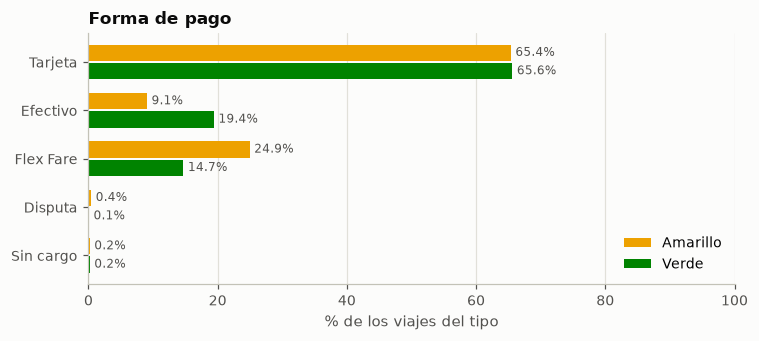

In [14]:
orden = ["Tarjeta", "Efectivo", "Flex Fare", "Disputa", "Sin cargo"]
d = pagos.pivot_table(index="forma_pago", columns="taxi", values="pct_viajes").reindex(orden)
y = np.arange(len(d))[::-1]
fig, eje = plt.subplots(figsize=(7, 3.2))
for i, taxi in enumerate(["yellow", "green"]):
    barras = eje.barh(y + (0.19 if i == 0 else -0.19), d[taxi], height=0.34, color=COLOR[taxi], label=NOMBRE[taxi])
    eje.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=8, color="#52514e")
eje.set_yticks(y, d.index)
eje.grid(axis="y", visible=False)
eje.grid(axis="x", visible=True)
eje.set_xlim(0, 100)
eje.set_xlabel("% de los viajes del tipo")
eje.legend(loc="lower right")
eje.set_title("Forma de pago")
fig.tight_layout()

La tarjeta cubre el 65% de los viajes en los dos tipos. Con tarjeta, el 91% de los viajes deja propina y la propina promedio equivale al 25.1% de la tarifa en amarillos y al 23.0% en verdes. En efectivo la propina registrada es cero en todos los viajes porque el taxímetro no la captura, así que el análisis de propinas se limita a los pagos con tarjeta.

### P7. ¿Qué parte del total son recargos y cambió alguno en 2026?

Para la composición del total se usan los viajes con tarjeta o efectivo, porque en Flex Fare faltan los recargos (ejercicio 3).

In [15]:
composicion = consulta("ej4/10_composicion_total.sql")
composicion.set_index("taxi").T

-- Monto promedio de cada componente del cobro en viajes pagados con tarjeta o efectivo
SELECT
    taxi,
    round(avg(fare_amount), 2) AS tarifa,
    round(avg(tip_amount), 2) AS propina,
    round(avg(tolls_amount), 2) AS peajes,
    round(avg(congestion_surcharge), 2) AS recargo_congestion,
    round(avg(cbd_congestion_fee), 2) AS cargo_cbd,
    round(avg(coalesce(Airport_fee, 0)), 2) AS cargo_aeropuerto,
    round(avg(extra + mta_tax + improvement_surcharge), 2) AS otros_recargos,
    round(avg(total_amount), 2) AS total
FROM viajes_validos
WHERE payment_type IN (1, 2)
GROUP BY taxi
ORDER BY taxi DESC



-- 0.34 s


taxi,yellow,green
tarifa,19.77,17.96
propina,3.74,2.92
peajes,0.59,0.20
recargo_congestion,2.26,0.92
cargo_cbd,0.55,0.07
cargo_aeropuerto,0.17,0.00
otros_recargos,3.01,2.55
total,29.53,24.42


In [16]:
consulta("ej4/11_cargo_aeropuerto.sql")

-- Viajes amarillos por valor del cargo de aeropuerto y mes
SELECT
    periodo,
    count(*) FILTER (WHERE Airport_fee = 1.75) AS cargo_1_75,
    count(*) FILTER (WHERE Airport_fee = 2.00) AS cargo_2_00,
    count(*) FILTER (WHERE Airport_fee NOT IN (1.75, 2.00)) AS otro_valor,
    min(pickup_datetime) FILTER (WHERE Airport_fee = 2.00) AS primer_cargo_2_00
FROM viajes_validos
WHERE taxi = 'yellow' AND Airport_fee > 0
GROUP BY periodo
ORDER BY periodo

-- 0.12 s


,periodo,cargo_1_75,cargo_2_00,otro_valor,primer_cargo_2_00
0,2026-01-01,222592,0,0,NaT
1,2026-02-01,190562,0,1,NaT
2,2026-03-01,110994,129411,0,2026-03-15 00:00:09
3,2026-04-01,0,240204,0,2026-04-01 00:00:19
4,2026-05-01,0,246949,0,2026-05-01 00:00:00
5,2026-06-01,0,241391,0,2026-06-01 00:00:02
6,2026-07-01,0,232589,0,2026-07-01 00:00:13
7,2026-08-01,0,231839,0,2026-08-01 00:00:29


En un viaje amarillo de 29.53 dólares, la tarifa es de 19.77, la propina de 3.74, los peajes de 0.59 y los recargos de 5.99, que se reparten en congestión 2.26, cargo CBD 0.55, aeropuerto 0.17 y 3.01 entre extra, impuesto MTA y recargo de mejora. Los componentes no siempre suman el total. En el 18% de los viajes amarillos con tarjeta o efectivo la diferencia pasa de un centavo.

El cargo de aeropuerto pasó de 1.75 a 2.00 dólares. El primer viaje con 2.00 empezó el 15 de marzo de 2026 a las 00:00:09, y desde abril ya no aparece 1.75.

### P8. ¿Qué explica los totales atípicos entre los viajes válidos?

Viajes con total mayor a Q3 más tres veces el rango intercuartil, agrupados por código de tarifa.

In [17]:
consulta("ej4/12_atipicos.sql")

-- Viajes válidos con total mayor a Q3 + 3 * IQR, agrupados por código de tarifa
WITH limites AS (
    SELECT
        taxi,
        quantile_cont(total_amount, 0.75)
            + 3 * (quantile_cont(total_amount, 0.75) - quantile_cont(total_amount, 0.25)) AS limite
    FROM viajes_validos
    GROUP BY taxi
)
SELECT
    v.taxi,
    round(l.limite, 2) AS limite_total,
    CASE v.RatecodeID
        WHEN 1 THEN 'Estándar'
        WHEN 2 THEN 'JFK'
        WHEN 3 THEN 'Newark'
        WHEN 4 THEN 'Nassau o Westchester'
        WHEN 5 THEN 'Negociada'
        WHEN 6 THEN 'Grupal'
        WHEN 99 THEN 'Desconocida'
        ELSE 'Sin dato'
    END AS tarifa,
    count(*) AS viajes,
    round(100 * count(*) / sum(count(*)) OVER (PARTITION BY v.taxi), 1) AS pct_atipicos,
    round(avg(v.trip_distance), 1) AS distancia_prom,
    round(avg(v.total_amount), 2) AS total_prom
FROM viajes_validos AS v
JOIN limites AS l USING (taxi)
WHERE v.total_amount > l.limite
GROUP BY v.taxi, l.limite, tarifa
ORDE

-- 2.34 s


,taxi,limite_total,tarifa,viajes,pct_atipicos,distancia_prom,total_prom
0,yellow,85.50,JFK,539270,51.1,18.0,97.95
1,yellow,85.50,Estándar,232699,22.1,16.6,100.20
2,yellow,85.50,Negociada,100202,9.5,9.7,116.52
3,yellow,85.50,Sin dato,81086,7.7,14.4,106.40
4,yellow,85.50,Newark,55270,5.2,17.1,125.55
5,yellow,85.50,Nassau o Westchester,45524,4.3,25.5,172.24
6,yellow,85.50,Desconocida,1049,0.1,21.2,94.32
7,green,73.44,Negociada,3434,47.1,10.4,105.48
8,green,73.44,Estándar,2115,29.0,15.5,94.23
9,green,73.44,Sin dato,885,12.1,19.1,90.11


Con esa regla, un total amarillo es atípico desde 85.50 dólares. El 51.1% de esos viajes usa la tarifa fija de JFK, que representa el 2.3% de todos los viajes amarillos válidos. Le siguen la tarifa estándar con distancias largas (16.6 millas en promedio), la tarifa negociada, los Flex Fare sin código de tarifa, Newark y Nassau o Westchester. En verdes la tarifa negociada explica el 47.1% de los atípicos. Los totales altos que quedan después del filtro corresponden a tipos de tarifa conocidos y no a errores.

### P9. ¿Cuántos viajes son Flex Fare y de dónde vienen?

In [18]:
flex = consulta("ej4/13_flex_fare.sql")
flex

-- Viajes Flex Fare por mes y origen de la solicitud
SELECT
    taxi,
    periodo,
    count(*) AS viajes,
    round(100 * avg((coalesce(payment_type, 0) = 0)::INT), 1) AS pct_flex_fare,
    count(*) FILTER (WHERE request_source = 'HV0003') AS origen_hv0003,
    count(*) FILTER (WHERE request_source = 'HV0005') AS origen_hv0005,
    count(*) FILTER (WHERE request_source NOT IN ('HV0003', 'HV0005')) AS otro_origen
FROM viajes_validos
GROUP BY taxi, periodo
ORDER BY taxi DESC, periodo



-- 0.32 s


,taxi,periodo,viajes,pct_flex_fare,origen_hv0003,origen_hv0005,otro_origen
0,yellow,2026-01-01,3515440,28.3,0,0,0
1,yellow,2026-02-01,3209333,28.9,0,0,0
2,yellow,2026-03-01,3761730,22.9,0,0,0
3,yellow,2026-04-01,3673102,20.2,0,0,0
4,yellow,2026-05-01,3910896,22.5,0,0,0
5,yellow,2026-06-01,3645451,25.3,843292,0,78639
6,yellow,2026-07-01,3345122,26.2,671883,0,205531
7,yellow,2026-08-01,3162692,26.5,576078,162312,100269
8,green,2026-01-01,38564,13.7,0,0,0
9,green,2026-02-01,35578,14.7,0,0,0


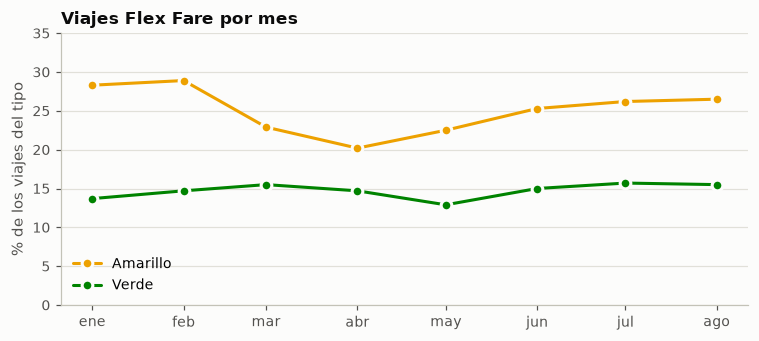

In [19]:
fig, eje = plt.subplots(figsize=(7, 3.2))
for taxi in ["yellow", "green"]:
    d = flex[flex.taxi == taxi]
    eje.plot(d.periodo, d.pct_flex_fare, color=COLOR[taxi], label=NOMBRE[taxi], marker="o", markersize=7,
             markeredgecolor="#fcfcfb", markeredgewidth=2)
eje.set_xticks(d.periodo, [MESES[p.month - 1] for p in d.periodo])
eje.set_ylim(0, 35)
eje.set_ylabel("% de los viajes del tipo")
eje.legend(loc="lower left")
eje.set_title("Viajes Flex Fare por mes")
fig.tight_layout()

Flex Fare representa entre el 20.2% y el 28.9% de los viajes amarillos de cada mes y entre el 12.9% y el 15.7% de los verdes. Desde junio, cuando aparece request_source, casi todos esos viajes traen un origen. En amarillos domina HV0003, con 843,292 viajes en junio, y HV0005 aparece por primera vez en agosto con 162,312. En el diccionario de viajes de vehículos de alto volumen de la TLC, HV0003 y HV0005 son las licencias de Uber y Lyft.

## 4.5 Hallazgos

1. Una cuarta parte de los viajes amarillos llega sin datos de pasajeros, código de tarifa ni recargos. Son los viajes Flex Fare, el 24.9% de los amarillos válidos y el 14.7% de los verdes. Desde junio de 2026 se ve que la mayoría se pidió por la licencia HV0003 (Uber), y en agosto entra HV0005 (Lyft). Cualquier promedio de pasajeros o recargos de 2026 deja fuera esos viajes.
2. Los taxis verdes trabajan en otra parte de la ciudad. El 40.1% de sus viajes empieza en East Harlem, tienen pico de mañana en días hábiles y bajan en fin de semana, mientras los amarillos tienen su máximo el sábado y el 86.6% empieza en Manhattan. Los verdes usan el doble de efectivo y casi no pagan el cargo CBD.
3. El cargo de aeropuerto subió de 1.75 a 2.00 dólares el 15 de marzo de 2026. El cambio se ve en los datos desde ese día y no figura en el diccionario de datos.
4. Los totales altos se explican por el tipo de tarifa. La mitad de los atípicos amarillos son viajes a JFK con tarifa fija, así que filtrar por monto sin mirar RatecodeID borraría viajes reales.
5. La demanda amarilla bajó 19% entre mayo y agosto, de 126 mil a 102 mil viajes por día. La comparación con 2024 y 2025 en los ejercicios 5 y 8 dirá si se repite cada verano.